In [1]:
import mido
mid = mido.MidiFile(r"C:\Users\wassim\Downloads\Improvise-a-Jazz-Solo-main\data\original_metheny.mid")

In [2]:
##pour parcourir les informations du fichier,vous pouvez écrire les lignes en bas sans le "#"
#for i, track in enumerate(mid.tracks):
    #print(f'Piste {i}: {track.name}')
    #for msg in track:
        ## C'est ici que tu vas voir passer les notes
        #if not msg.is_meta: # On ignore les infos de tempo/nom
            #print(msg)

In [3]:
accords_extraits = []
sac_de_notes = []

for msg in mid:
    if msg.type == 'note_on' and msg.velocity > 0:
        if msg.time == 0:
            sac_de_notes.append(msg.note)
        else:
            if sac_de_notes:
                # On trie pour que (60, 64) soit égal à (64, 60)
                accords_extraits.append(tuple(sorted(sac_de_notes)))
            sac_de_notes = [msg.note]

In [4]:
# set() supprime automatiquement tous les doublons
unique_chords = sorted(list(set(accords_extraits)))

# On crée un dictionnaire : { Accord : ID }
chord_to_id = {chord: i for i, chord in enumerate(unique_chords)}

# On crée aussi l'inverse (pour décoder plus tard) : { ID : Accord }
id_to_chord = {i: chord for chord, i in chord_to_id.items()}

print(f"Nombre de 'musical values' uniques trouvées : {len(unique_chords)}")

Nombre de 'musical values' uniques trouvées : 1212


In [5]:
# On traduit chaque accord du morceau en son ID correspondant
values_dataset = [chord_to_id[accord] for accord in accords_extraits]

# Vérification
print(f"Longueur du morceau en nombre de notes/accords : {len(values_dataset)}")
print(f"Exemple des 5 premiers entiers : {values_dataset[:5]}")

Longueur du morceau en nombre de notes/accords : 6313
Exemple des 5 premiers entiers : [270, 34, 619, 619, 619]


In [6]:
def creer_X_et_Y(data, Tx):
    X = []
    Y = []
    
    # On s'arrête Tx notes avant la fin pour avoir de la place pour Y
    for i in range(len(data) - Tx):
        # On prend une tranche (slice) de Tx notes
        X.append(data[i : i + Tx])
        # On prend la note qui suit immédiatement la tranche
        Y.append(data[i + Tx])
        
    return X, Y

In [7]:
import numpy as np
X,Y=creer_X_et_Y(data=values_dataset, Tx=30)
X = np.array(X)
Y = np.array(Y)
print('dimension de X:', X.shape)
print('dimansion de Y:', Y.shape)

dimension de X: (6283, 30)
dimansion de Y: (6283,)


In [8]:
print(X)

[[ 270   34  619 ...  619  619  270]
 [  34  619  619 ...  619  270  619]
 [ 619  619  619 ...  270  619  406]
 ...
 [1100 1167  212 ... 1100 1103  194]
 [1167  212 1004 ... 1103  194 1074]
 [ 212 1004 1123 ...  194 1074 1123]]


In [9]:
print(Y)

[ 619  406  197 ... 1074 1123 1100]


In [10]:
import tensorflow as tf

n_values = len(unique_chords) # Le nombre d'accords uniques (ex: 1211)

X_oh = tf.one_hot(X, depth=n_values)
Y_oh = tf.one_hot(Y, depth=n_values)

In [11]:
from tensorflow.keras.layers import Dense, Activation, Dropout, Input, LSTM, Reshape, Lambda, RepeatVector
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
n_a=256
reshaper = Reshape((1, n_values))                  
LSTM_cell_1= LSTM(n_a, return_state = True)
LSTM_cell_2= LSTM(n_a, return_state = True)
densor = Dense(n_values, activation='softmax')   

In [12]:
def djmodel(Tx, LSTM_cell_1, LSTM_cell_2, densor, reshaper):
    #étape 1:définir a0,c0 et X
    
    # 1. L'entrée des notes (X)
    # Shape : (Nombre de pas de temps, Nombre d'accords uniques)
    X = Input(shape=(Tx, n_values)) 
    
    # 2. L'état caché initial (a0)
    # Shape : (Nombre de neurones du LSTM,)
    a1_0 = Input(shape=(n_a,), name='a1_0')
    a1=a1_0

    a2_0=Input(shape=(n_a,), name='a2_0')
    a2=a2_0
    
    # 3. L'état de cellule initial (c0)
    # Shape : (Nombre de neurones du LSTM,)
    c1_0 = Input(shape=(n_a,), name='c1_0')
    c1=c1_0

    c2_0 = Input(shape=(n_a,), name='c2_0')
    c2=c2_0
    
    #pour stoquer les sorties
    outputs = []
    
    #pour avoir les bonnes dimensions 
    repeater = RepeatVector(1)
    dropout_layer = Dropout(0.3)
    #étape 2:boucle for
    
    for t in range(Tx):
        #on prend la note t dans la séquence X
        x = Lambda(lambda x: x[:, t, :])(X)

        #on change les dimensions du vecteur (1,n_values)
        x = reshaper(x)

        #on donne la note et la mémoire précédente au LSTM
        # le '_' signifie on ignore la sortie intermédiaire pour ne garder que l'état caché et l'état de cellule.
        a1, _, c1 = LSTM_cell_1(x, initial_state=[a1, c1])

        #on va rajouter un drop out
        a1_dropout = dropout_layer(a1)

        #On prépare a1 pour la deuxième couche en changeant sa dimension (2D -> 3D)
        a1_for_l2 = repeater(a1_dropout)

        a2, _, c2 = LSTM_cell_2(a1_for_l2, initial_state=[a2, c2])
        
        #on passe a dans le densor pour obtenir les probabilitées
        out = densor(a2)

        #on la stoque dans la liste outputs
        outputs.append(out)

        #étape 3:on défini les entrées et sortie du modele
        model = Model(inputs=[X, a1_0,a2_0,c1_0,c2_0], outputs=outputs)

    return model

In [13]:
model = djmodel(Tx=30, LSTM_cell_1=LSTM_cell_1 ,LSTM_cell_2=LSTM_cell_2, densor=densor, reshaper=reshaper)

In [14]:
model.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 30, 1212)          │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 1212)              │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 1, 1212)           │               0 │ lambda[0][0],              │
│                               │                           │                 │ lambda_1[0][0],            │
│                               │                           │                 │ lambda_2[0][0],            │
│                               │                           │                 │ lambda_3[0][0],            │
│                               │                           │                 │ lambda_4[0][0],            │
│                               │                           │                 │ lambda_5[0][0],            │
│                               │                           │                 │ lambda_6[0][0],            │
│                               │                           │                 │ lambda_7[0][0],            │
│                               │                           │                 │ lambda_8[0][0],            │
│                               │                           │                 │ lambda_9[0][0],            │
│                               │                           │                 │ lambda_10[0][0],           │
│                               │                           │                 │ lambda_11[0][0],           │
│                               │                           │                 │ lambda_12[0][0],           │
│                               │                           │                 │ lambda_13[0][0],           │
│                               │                           │                 │ lambda_14[0][0],           │
│                               │                           │                 │ lambda_15[0][0],           │
│                               │                           │                 │ lambda_16[0][0],           │
│                               │                           │                 │ lambda_17[0][0],           │
│                               │                           │                 │ lambda_18[0][0],           │
│                               │                           │                 │ lambda_19[0][0],           │
│                               │                           │                 │ lambda_20[0][0],           │
│                               │                           │                 │ lambda_21[0][0],           │
│                               │                           │                 │ lambda_22[0][0],           │
│                               │                           │                 │ lambda_23[0][0],           │
│                               │                           │                 │ lambda_24[0][0],           │
│                               │                           │                 │ lambda_25[0][0],           │
│                               │                           │                 │ lambda_26[0][0],           │
│                               │                           │                 │ lambda_27[0][0],           │
│                               │                           │                 │ lambda_28[0][0],           │
│                               │                           │               

 Total params: 2,341,052 (8.93 MB)

 Trainable params: 2,341,052 (8.93 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from livelossplot import PlotLossesKeras

metrique_liste = [None] * 29 + ['accuracy']

# On utilise 'categorical_crossentropy' car on a fait du One-Hot
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=metrique_liste)

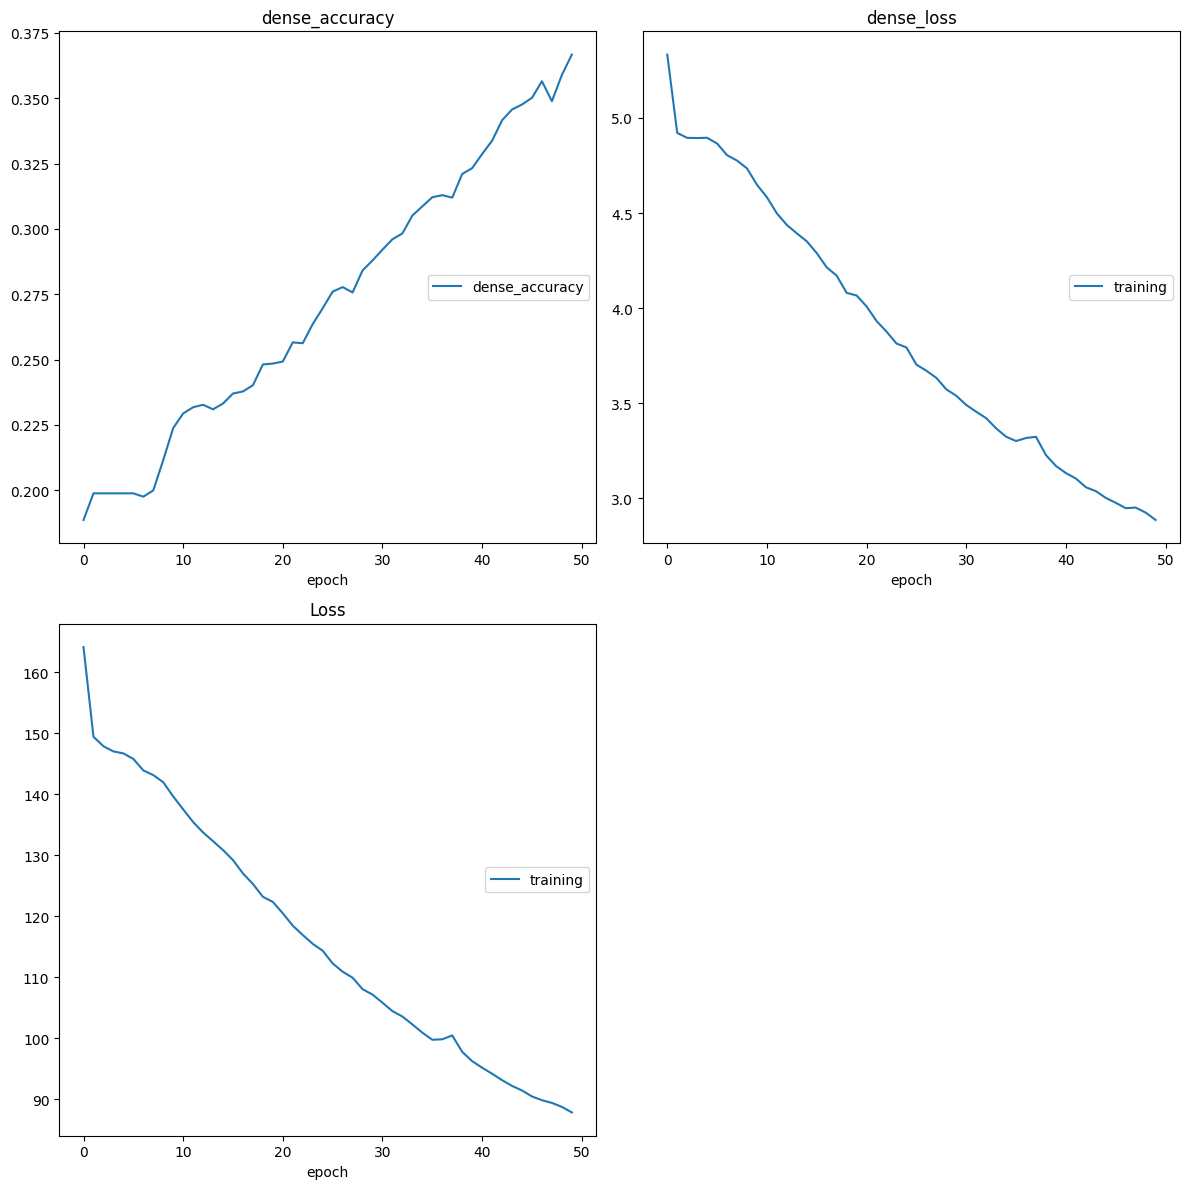

dense_accuracy
	dense_accuracy   	 (min:    0.189, max:    0.367, cur:    0.367)
dense_loss
	training         	 (min:    2.887, max:    5.333, cur:    2.887)
Loss
	training         	 (min:   87.870, max:  164.115, cur:   87.870)
99/99 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - dense_accuracy: 0.3725 - dense_loss: 2.8692 - loss: 87.4137


In [16]:
# On crée une liste qui contient 30 fois le tableau Y_oh
# Pour que chaque sortie 't' du modèle ait sa propre cible 'y'
Y_list = [Y_oh for _ in range(30)]

# 1. On récupère le nombre d'exemples (m)
m = X_oh.shape[0] 

# 2. On crée les états initiaux remplis de zéros
# Ils doivent avoir la forme (m, n_a)
a1_0 = np.zeros((m, n_a))
c1_0 = np.zeros((m, n_a))

a2_0 = np.zeros((m, n_a))
c2_0 = np.zeros((m, n_a))


# 3. Maintenant nous pouvons lancer l'entraînement
history = model.fit(
    [X_oh, a1_0, c1_0,a2_0,c2_0],Y_list, 
    epochs=50,batch_size=64,verbose=1, # Optionnel mais conseillé pour la vitesse
    callbacks=[PlotLossesKeras()]
)

In [22]:
from keras.layers import Lambda
def music_inference_model(LSTM_cell_1,LSTM_cell_2, densor, n_values, n_a, Ty=50):
    # 1. Définir les entrées (une seule note à la fois cette fois !)
    x0 = Input(shape=(1, n_values))
    a1_0 = Input(shape=(n_a,), name='a1_0')
    c1_0 = Input(shape=(n_a,), name='c1_0')
    a2_0 = Input(shape=(n_a,), name='a2_0')
    c2_0 = Input(shape=(n_a,), name='c2_0')
    
    # Initialiser a, c et x avec les entrées
    a1 = a1_0
    c1 = c1_0
    a2 = a2_0
    c2 = c2_0
    x = x0
    
    outputs = []
    repeater = RepeatVector(1)
    
    # 2. Boucle pour générer Ty notes (ex: 100 notes)
    for t in range(Ty):
        # A. Un pas de LSTM
        a1, _, c1 = LSTM_cell_1(x, initial_state=[a1, c1])

        a1_LSTM_2=repeater(a1)
        
        a2, _, c2 = LSTM_cell_2(a1_LSTM_2, initial_state=[a2, c2])
        
        # B. Prédire la note suivante
        out = densor(a2)
        outputs.append(out)
        
        # C. TRÈS IMPORTANT : La sortie "out" devient l'entrée "x" du tour suivant !
        # On utilise une sélection (Argmax) pour choisir la note la plus probable
        idx = Lambda(lambda z: tf.math.argmax(z, axis=-1))(out)
        x = Lambda(lambda z: tf.one_hot(tf.cast(z, tf.int32), depth=n_values))(idx)
        x = RepeatVector(1)(x) # Pour garder la forme (1, n_values)

    # 3. Créer le modèle d'inférence
    inference_model = Model(inputs=[x0, a1_0,a2_0,c1_0,c2_0], outputs=outputs)
    return inference_model

In [23]:
inference_model = music_inference_model(LSTM_cell_1,LSTM_cell_2, densor, n_values, n_a, Ty=120)

In [38]:
#la fonction predict_and_sample permet de transformer les probabilitées en décision
def predict_and_sample(inference_model,x_initializer, a1_initializer, c1_initializer,a2_initializer, c2_initializer ,temperature=0.7 ):
    #le sampling
    #on utilise la fonction inference modele pour avoir une prediction
    pred = inference_model.predict([x_initializer, a1_initializer, c1_initializer,a2_initializer, c2_initializer])

    #on crée une liste indice vide
    indices = []
    
    for t in range(len(pred)):
        
        # On récupère les probabilités du pas de temps t 
        probs = np.copy(pred[t].ravel())
        
        #on va rajouter la temperature pour améliorer l'IA
        # Application de la température
        # 1. On applique le logarithme
        # 2. On divise par la température
        # 3. On reprend l'exponentielle pour retrouver des probabilités
        probs = np.log(probs + 1e-8) / temperature # 1e-8 évite le log(0)
        exp_probs = np.exp(probs)
        probs = exp_probs / np.sum(exp_probs)
        
        #ici on as deux possibilitées:
        #soit on utilise la fonction argmax pour garder que la plus grande probabilitée
        #le probléme c'est que certaines probabilitées seront toujours les plus grandes et donc il y aura beaucoup de répétition
        #soit on utilise np.random pour choisir une probabilitée aléatoire(c'est celle qu'on va prendre)
        #on parcour chaque probabilitée pour lui donnée un ID que nous traduirons avec le dictionnaire inverse id_to_chords
        idx = np.random.choice(range(n_values), p=probs.ravel())
        #On utilise np.random.choice pour simuler l'improvisation
        #une fois qu'on a l'indice on récupére l'indice en le rajoutant dans la liste indice
        indices.append(idx)
    return indices

In [40]:
#la fonction generate_music sert de traducteur entre les indices récupérés en haut et le dictionnaire pour les générées en fichier MIDI
from music21 import stream, note, chord
def generate_music(indices,id_to_chord):
    output_stream = stream.Stream()
    #output_stream permettra de stoquer les accords et les notes pour le fichier MIDI
    indices=predict_and_sample(inference_model, x_initializer, a1_initializer, c1_initializer,a2_initializer, c2_initializer)
    #on parcours les indices généré par l'IA
    for idx in indices:
        #on les traduit avec notre dictionnaire
        #il parcours les elements de la liste indice et regarde l'équivalent dans le dictionnaire 
        chord_name = id_to_chord[idx]
        #ensuite on Transforme le nom en objet musical
        # (Si le dictionnaire contient des accords complexes, 
        # il faudra peut-être parser la chaîne de caractères)
        # Si c'est un tuple(une liste à 3 élément exemple (60,8,7)) ou une liste, music21 le comprend directement
        if isinstance(chord_name, (tuple, list)):
            new_chord = chord.Chord(chord_name)
        else:
            # Au cas où certains soient encore du texte
            new_chord = chord.Chord(chord_name.replace(',', ' '))
            new_chord.volume.velocity = 64
        # enfin on ajoute l'objet à la piste
        output_stream.append(new_chord)
    #on crée le fichier sur le disque
    output_stream.write('midi', fp='mon_impro_jazz_4.mid')
    return output_stream

In [41]:
# 1. On prépare les entrées "vides" (le silence avant la musique)
x_initializer = np.zeros((1, 1, n_values))
a1_initializer = np.zeros((1, n_a))
c1_initializer = np.zeros((1, n_a))
a2_initializer = np.zeros((1, n_a))
c2_initializer = np.zeros((1, n_a))

# 2. On génère la liste d'indices avec l'âme de jazzman
print("Génération des notes...")
indices_generes = predict_and_sample(inference_model, x_initializer, a1_initializer, c1_initializer,a2_initializer, c2_initializer)

# 3. On transforme ça en fichier MIDI
print("Création du fichier MIDI...")
out_stream = generate_music(indices_generes, id_to_chord)

print("Terminé ! Ton morceau est prêt.")

Génération des notes...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
Création du fichier MIDI...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
Terminé ! Ton morceau est prêt.


In [42]:
# Sauvegarde le modèle d'entraînement (djmodel)
model.save('mon_modele_jazz_metheny.keras')

In [43]:
# Sauvegarde des poids uniquement
model.save_weights('jazz_weights.weights.h5')

In [44]:
#pour récupérer le modele on a 2 options:
#from keras.models import load_model

# Option A : Recharger le modèle complet en écrivant:
#mon_nouveau_modele = load_model('mon_modele_jazz_metheny.keras')

# Option B : Si vous avez déjà créé un objet 'inference_model', vous lui injectez les poids
# inference_model.load_weights('jazz_weights.weights.h5')